## Current workflow review copy

Synchronized with the completed 18 September 2026 uncalibrated engine run. Upstream construction/household methods are retained; notebooks 05 onward use outputs/current. Notebooks 03–04 have no saved demonstration outputs in the current source. Read [the workflow](../../docs/ENGINE_WORKFLOW.md) and [interpretation](../../docs/INTERPRETATION.md). Packaging does not rerun calculations. Raw data, address-level outputs and interactive payloads are excluded.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 06 · Validation against observed consumption

All 84 LSOAs, no ten-ward clipping. Gas/electricity are delivered energy. Observed means are per consuming meter; modelled means are per eligible dwelling. This is an annual external benchmark comparison, not untouched holdout validation.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from ukubem import unified as U, reporting as R
OUT = U.OUT
R.validation()
display(pd.Series(json.loads((U.BASE/'metrics.json').read_text())).round(3))

LOCAL_PATH/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
LOCAL_PATH/raw.py:723: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


gas_MAPE               0.071
elec_MAPE              0.104
gas_bias              -0.056
elec_bias              0.030
gas_WAPE_pct           7.278
elec_WAPE_pct         11.213
gas_NMBE_pct          -5.842
elec_NMBE_pct          1.393
gas_R2_predictive      0.893
elec_R2_predictive     0.695
J_gas                  0.008
J_elec                 0.017
dtype: float64

The grey band indicates ±10%, not a formal pass/fail threshold.

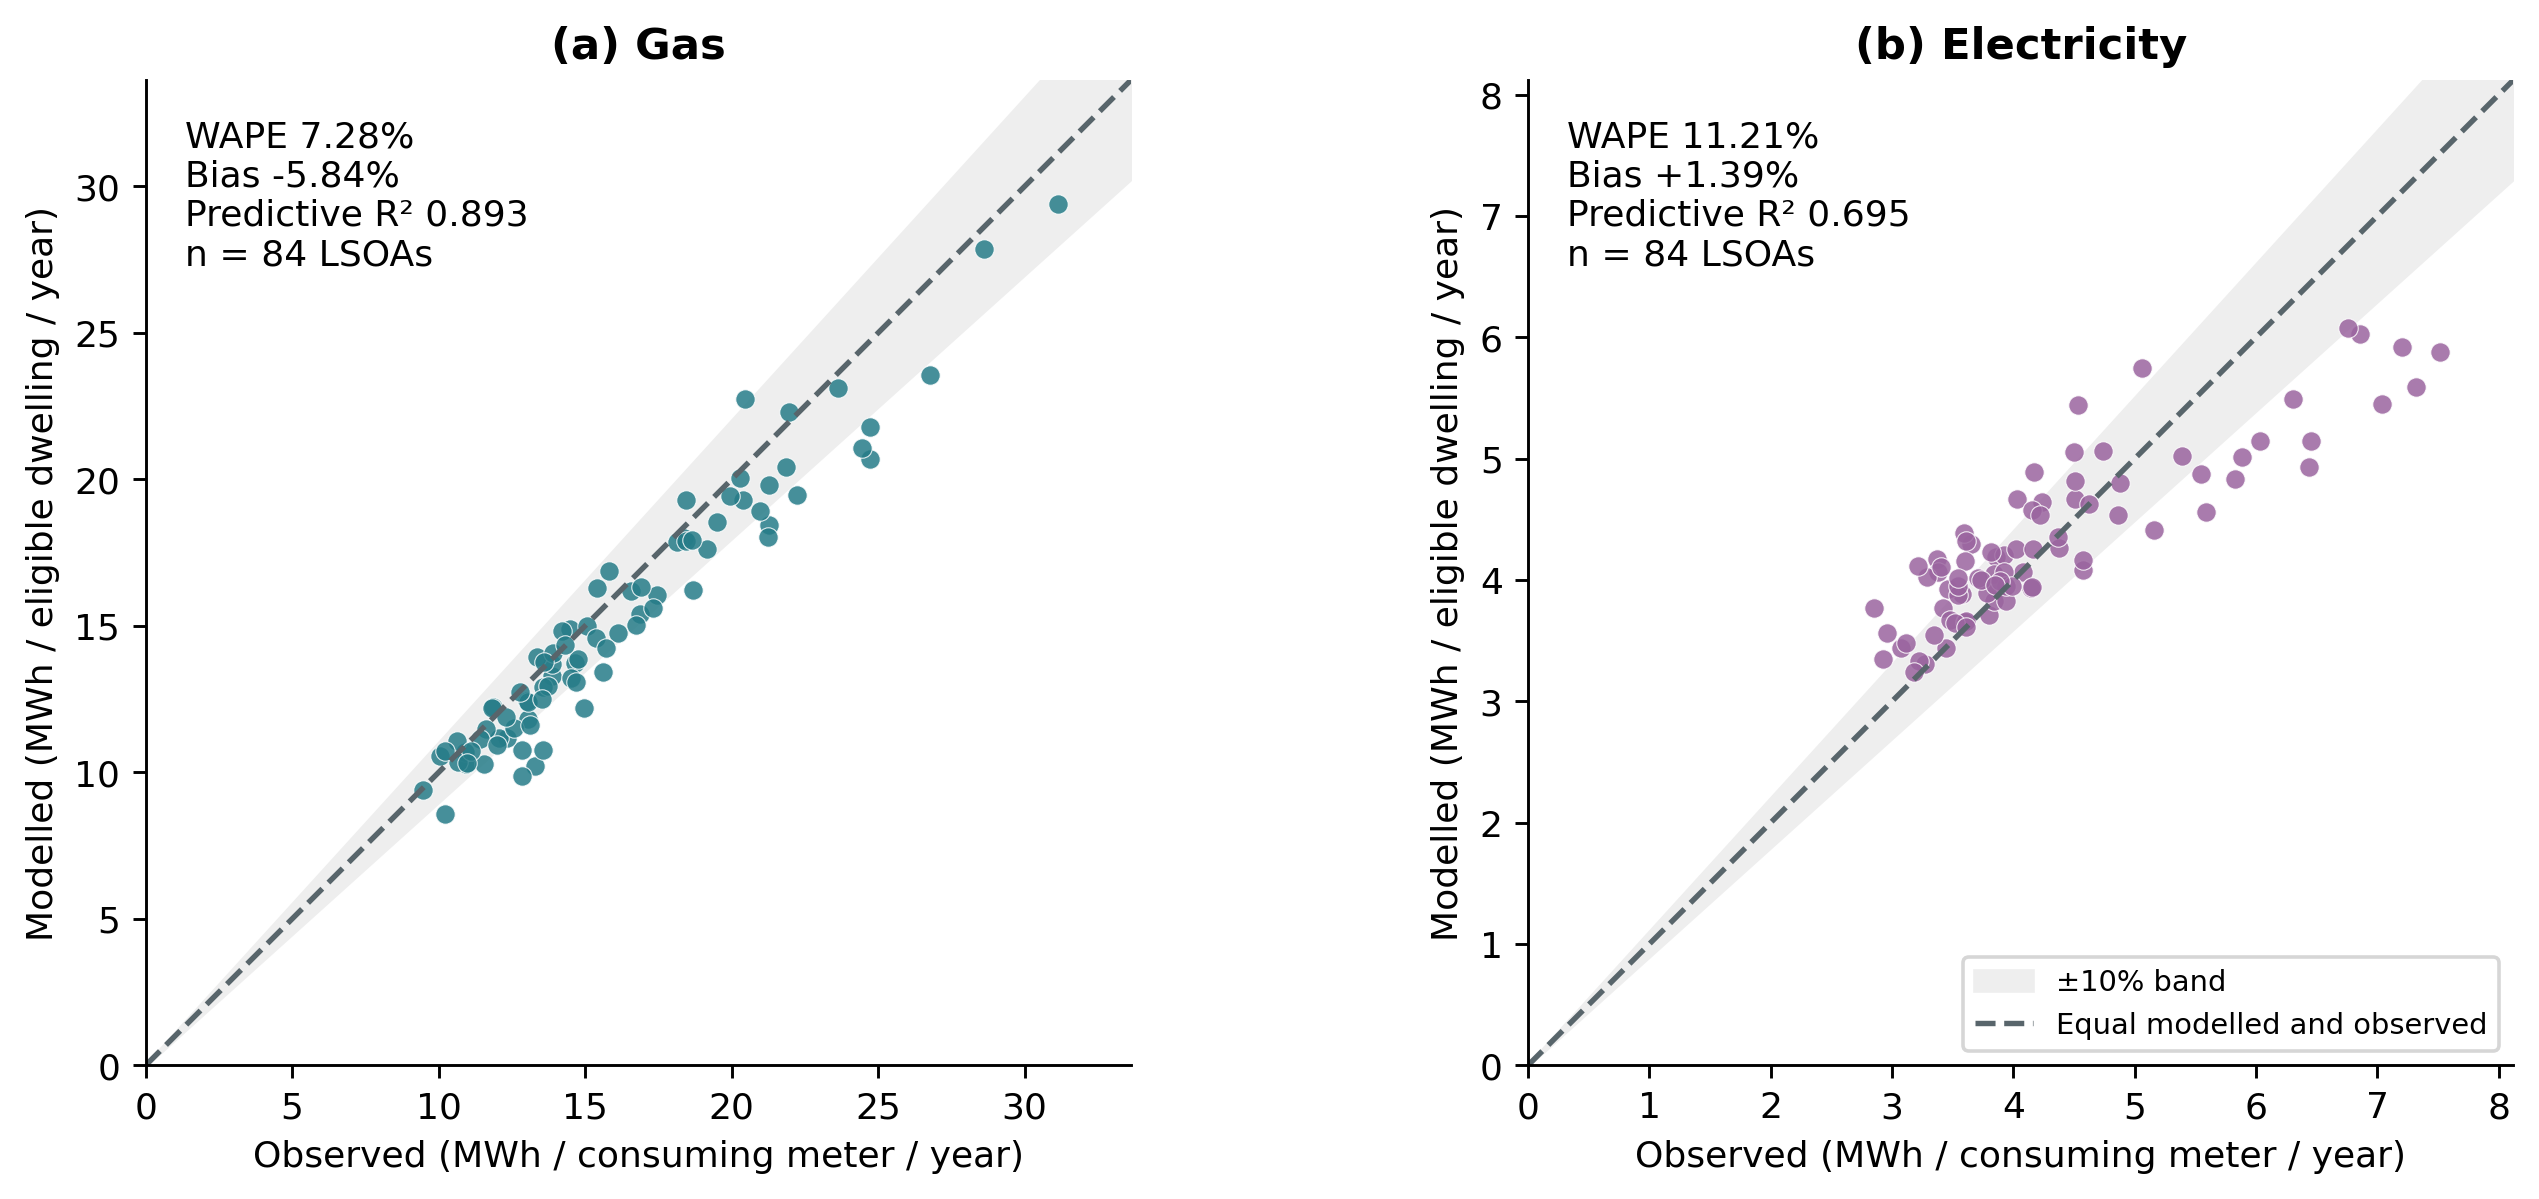

In [2]:
display(Image(filename=str(OUT/'figures/06_validation_observed_modelled.png')))

Red indicates overprediction and blue underprediction. Both fuels use the same scale.

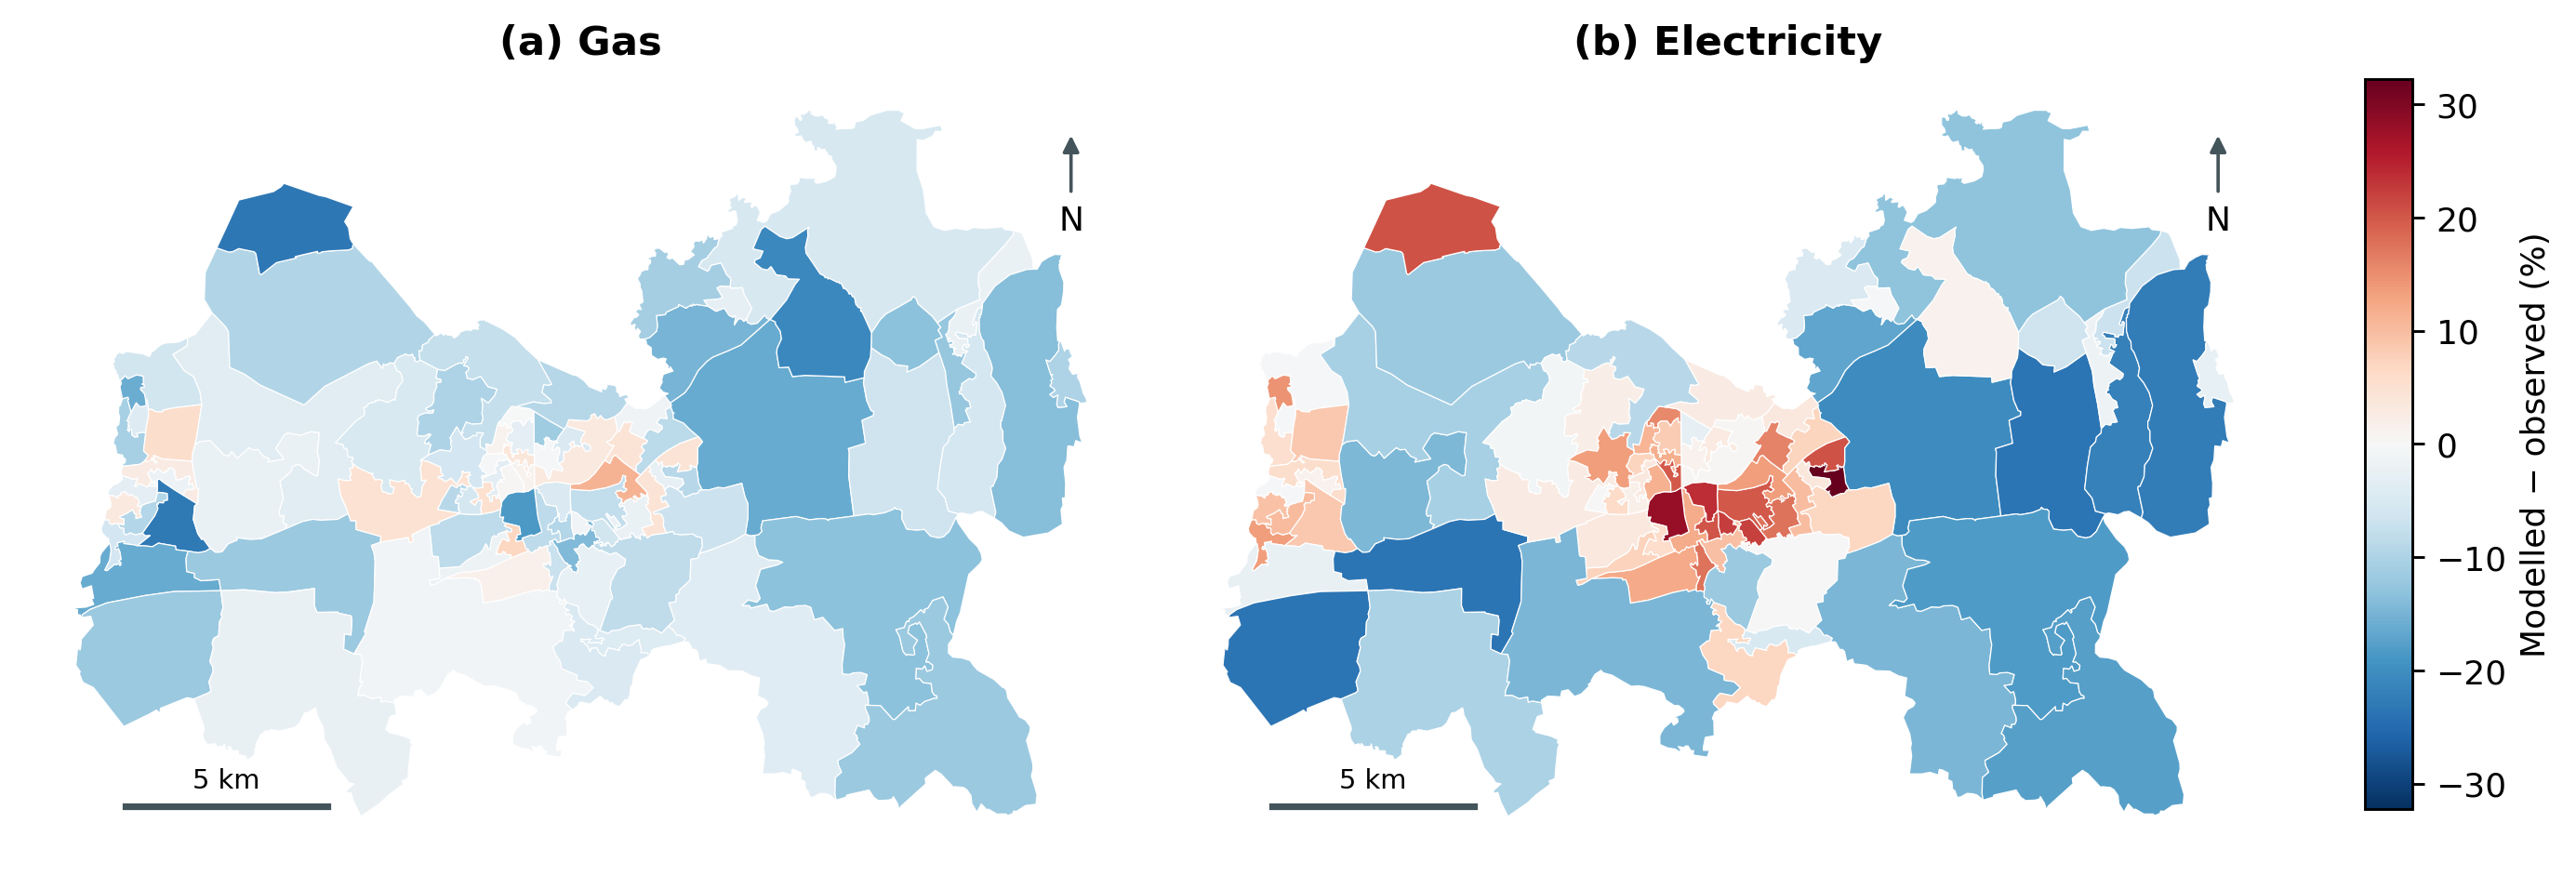

In [3]:
display(Image(filename=str(OUT/'figures/06_validation_maps.png')))

Canet-inspired presentation, not a reproduction of his gas-to-heat method. Signed error = 100 × (modelled − observed)/observed. Medians are not WAPE. Every point is retained.

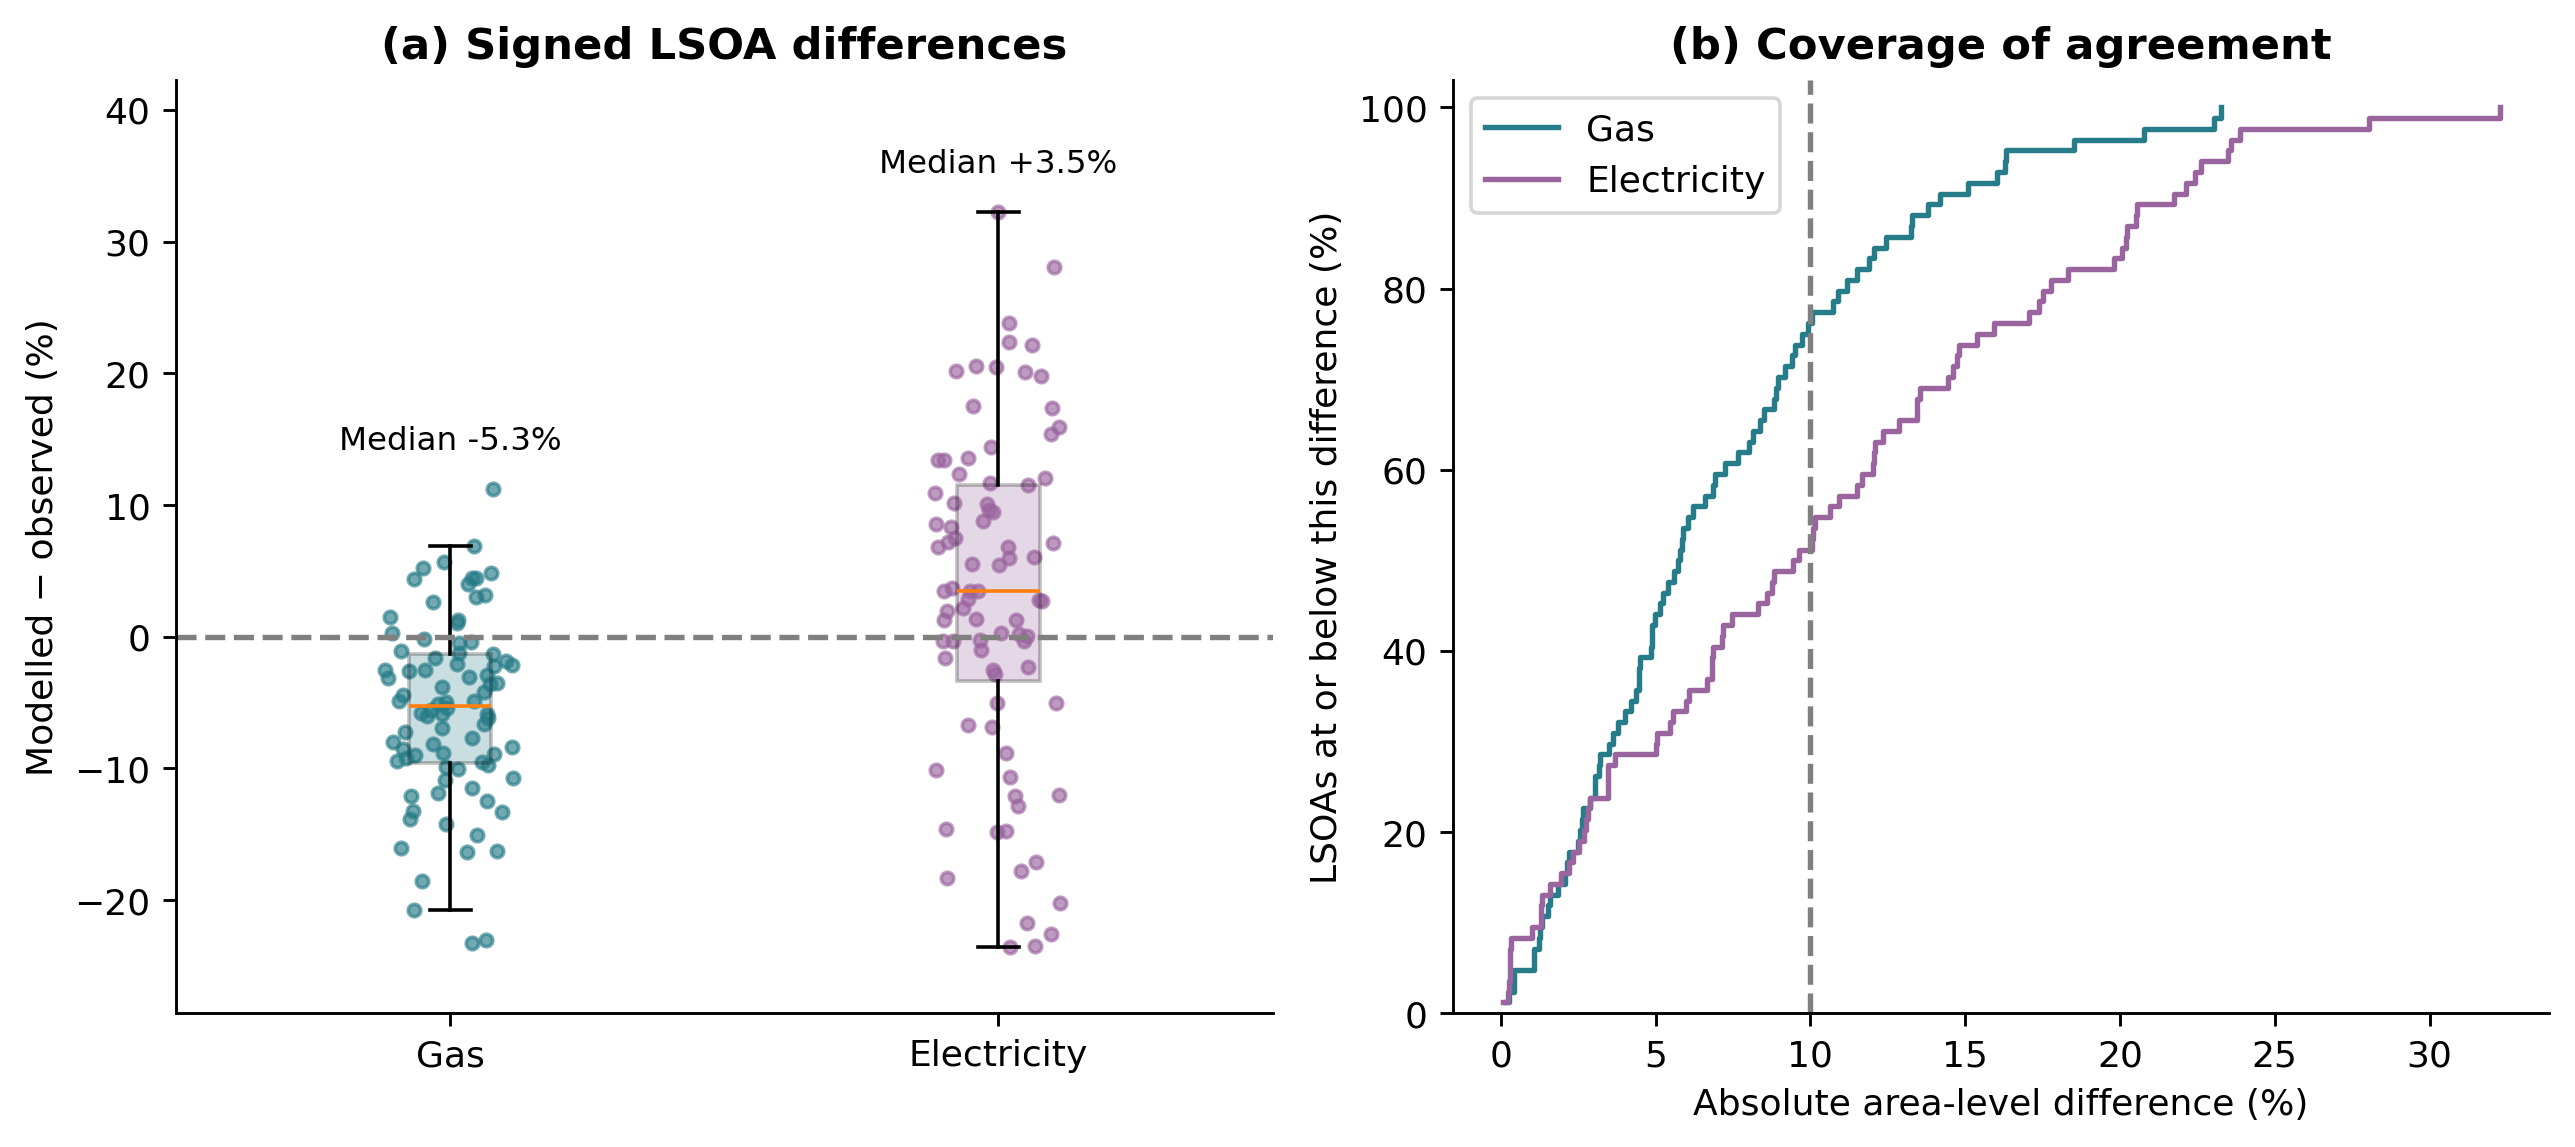

In [4]:
display(Image(filename=str(OUT/'figures/06_canet_style_distribution.png')))

Best/worst examples ranked by mean absolute gas/electricity percentage discrepancy.

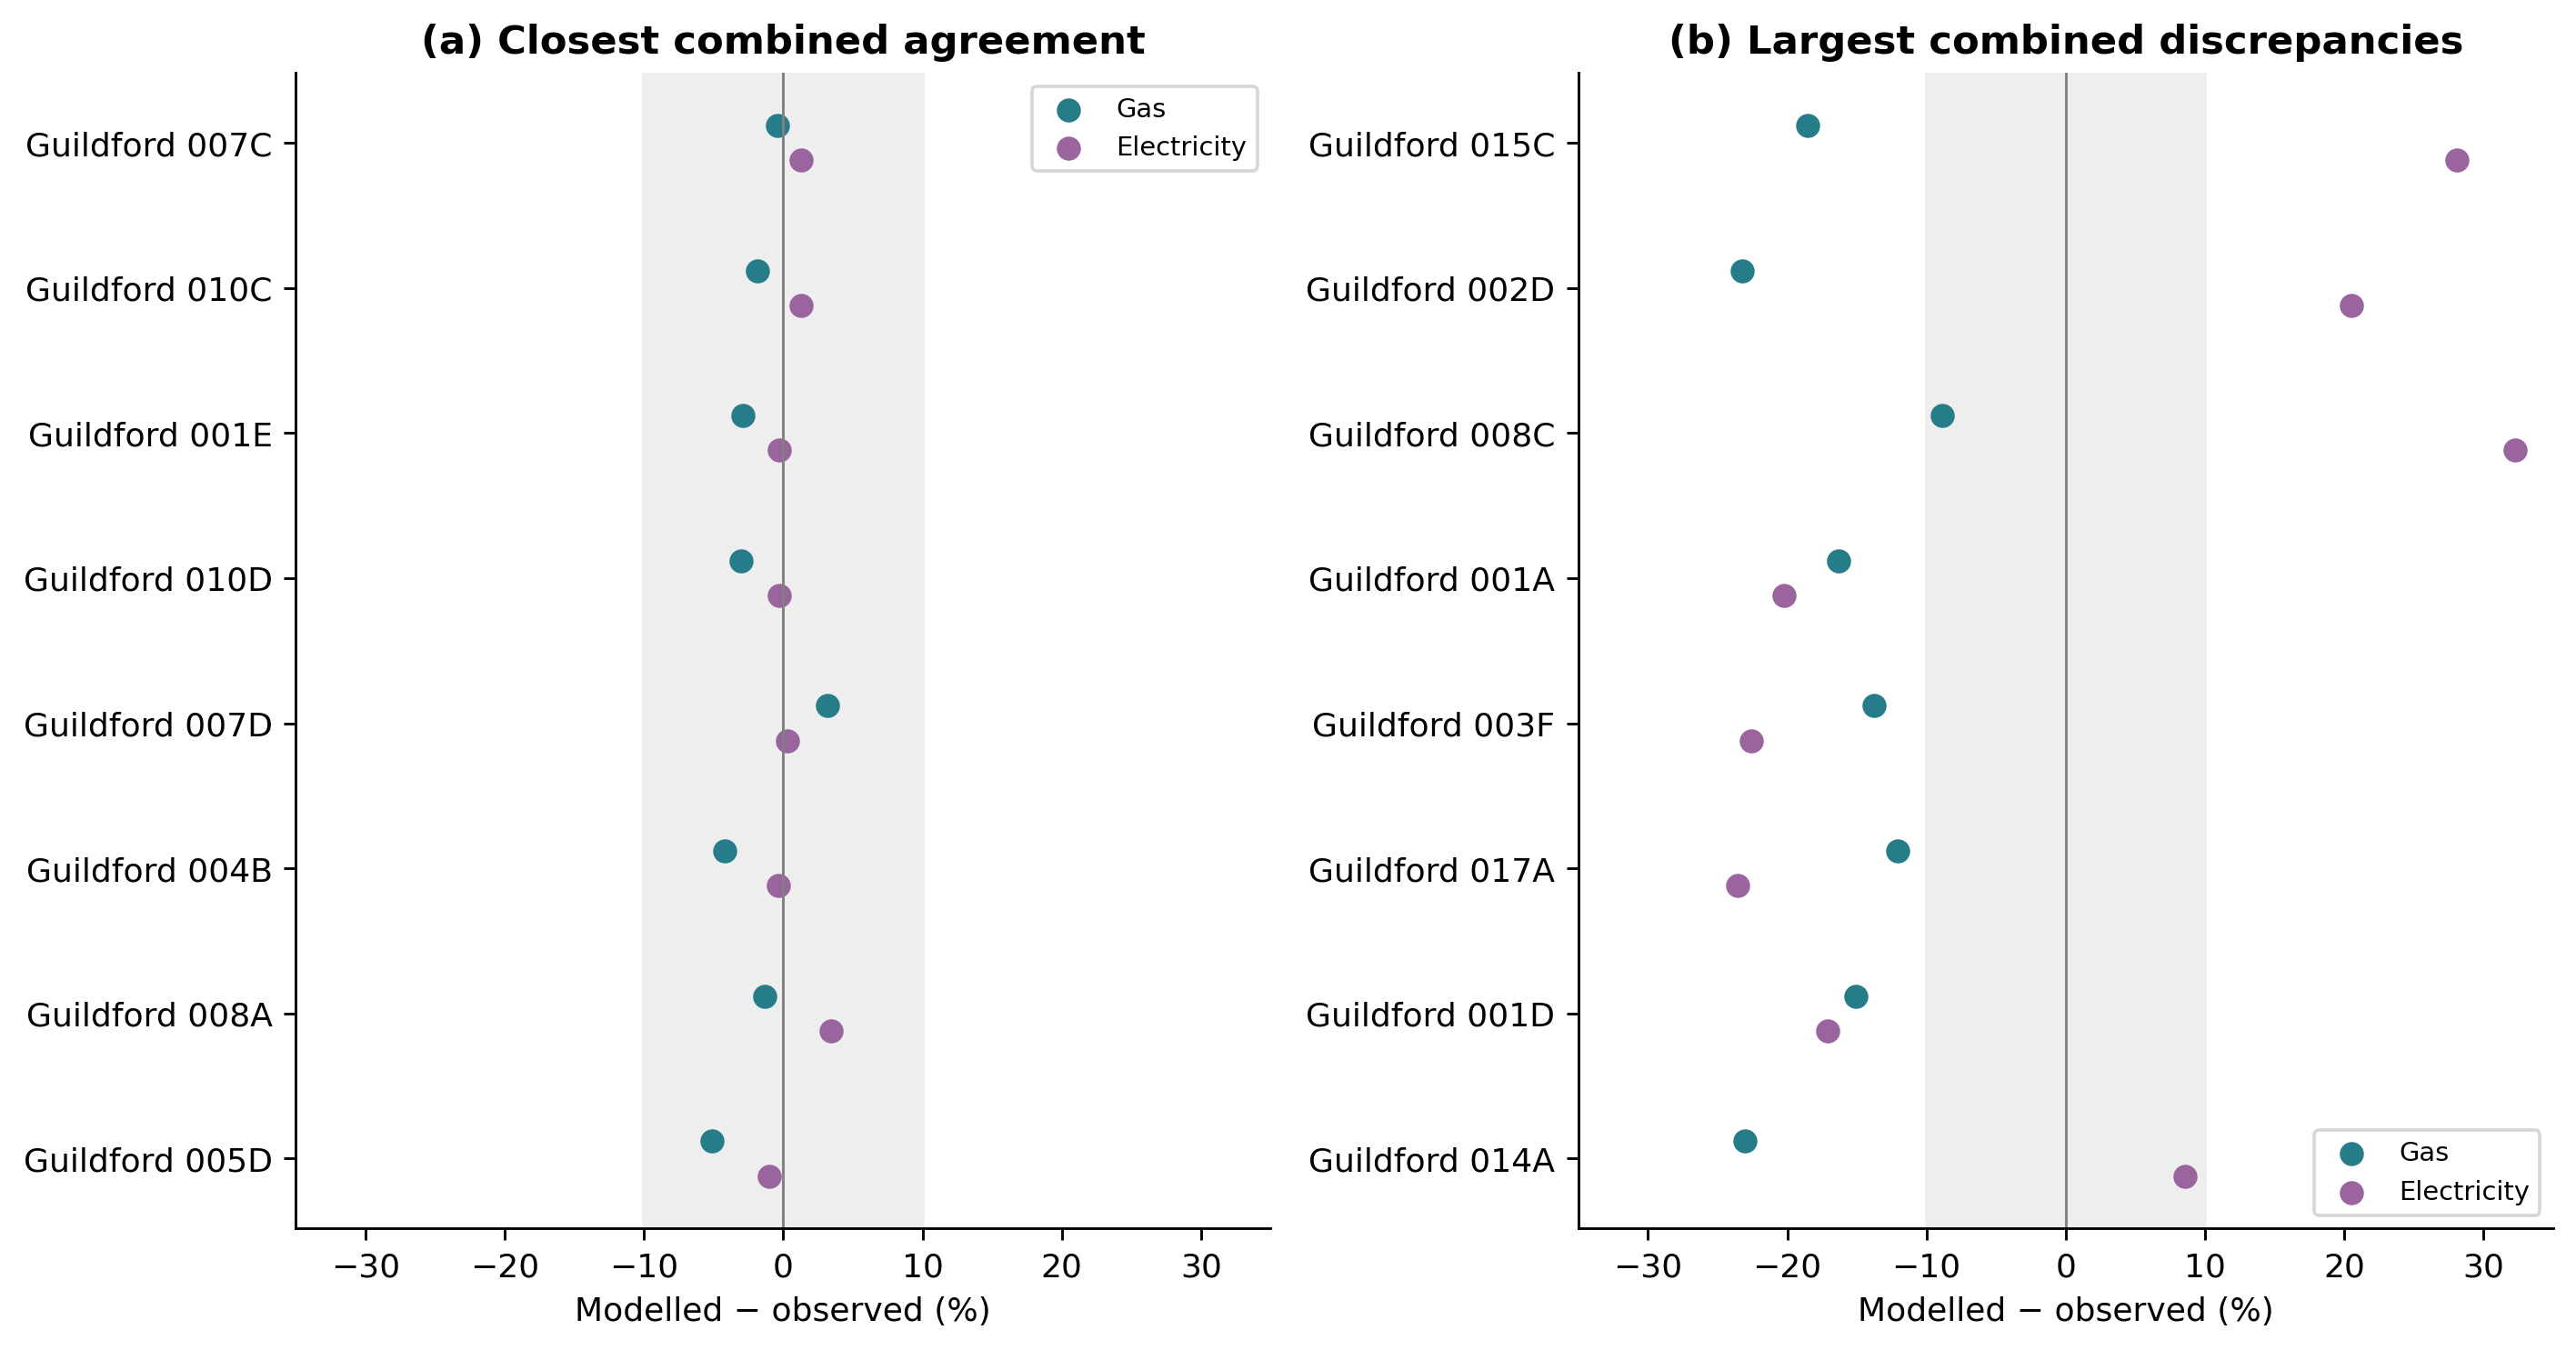

In [5]:
display(Image(filename=str(OUT/'figures/06_lsoa_alignment.png')))

In [6]:
display(Markdown((U.BASE/'DISCUSSION.md').read_text(encoding='utf-8')))

<IPython.core.display.Markdown object>